# 05 · Building the knowledge base

The chatbot is required to answer clinical questions using evidence drawn from the ophthalmology
literature rather than from the parametric knowledge encoded in the weights of the language model.
The first stage of the system therefore assembles a curated collection of trustworthy articles and
prepares them for subsequent use. This collection is termed the corpus.

The present notebook documents the composition of that corpus together with the reasoning behind
each design decision. It reads the finished corpus only, since the retrieval of the articles is
carried out once by the script `scripts/build_corpus.py`, which in turn relies on the functions
defined in `ocular/rag/corpus.py`.

## Where the articles come from

The corpus is drawn from PubMed Central (PMC), a public repository of biomedical research articles.
Only articles belonging to the Open Access subset are retained, since these are the articles whose
licences permit reuse.

Relevance to ophthalmology is enforced at the point of retrieval rather than through any subsequent
analysis of content. A keyword search would return a substantial number of articles that merely
mention an ophthalmic term in passing, and for this reason the search is instead restricted to a
fixed set of ophthalmology journals, referred to as the journal whitelist. An article that appears
in a journal such as Ophthalmology or Retina is by definition concerned with eye care, so the
publication venue itself provides sufficient evidence of relevance. This strategy removes any need
for an additional topical classifier.

In [1]:
import pandas as pd
from ocular.rag import corpus

meta = pd.read_csv(corpus.CORPUS_DIR / "metadata.csv")
print(f"articles in the corpus : {len(meta)}")
print(f"total text             : {meta.n_chars.sum():,} characters")
print(f"typical article        : {int(meta.n_sections.median())} sections, "
      f"{int(meta.n_chars.median()):,} characters")
meta.head()

articles in the corpus : 508
total text             : 13,715,492 characters
typical article        : 14 sections, 25,591 characters


,pmcid,title,doi,license,journal,n_sections,n_chars
0,PMC13499403,Topographically Resolved Macular Pigment Optic...,10.1016/j.xops.2026.101326,CC BY 4.0,Ophthalmology Science,12,18745
1,PMC13499576,Development of a Targeted Choroidal Injury Mod...,10.1167/tvst.15.8.17,CC BY 4.0,Translational Vision Science & Technology,13,29930
2,PMC13499034,Detection of Disease Progression Using Widefie...,10.1167/tvst.15.8.16,CC BY 4.0,Translational Vision Science & Technology,12,24184
3,PMC13498439,Reference Standard for Validation of Age-Relat...,10.1016/j.ophtha.2026.04.013,CC BY 4.0,Ophthalmology,9,21156
4,PMC13490247,Parental knowledge–attitude–practice profiles ...,10.1007/s00417-026-07272-7,CC BY 4.0,Graefe's Archive for Clinical and Experimental...,6,20097


## Which journals the articles come from

Each article originates from one of the whitelisted ophthalmology journals. The figure below
reports the journals that contribute the largest number of articles to the corpus.

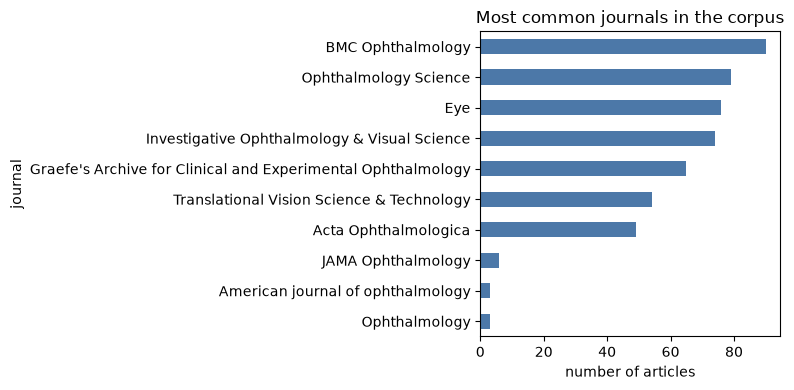

In [2]:
import matplotlib.pyplot as plt

top = meta["journal"].value_counts().head(10)
top.sort_values().plot.barh(figsize=(8, 4), color="#4C78A8")
plt.xlabel("number of articles")
plt.title("Most common journals in the corpus")
plt.tight_layout(); plt.show()

## Licensing and permitted reuse

Every open-access article is distributed under a licence that governs the ways in which it may be
used. Because the chatbot divides each article into small passages and supplies those passages to
the language model, the system both reproduces and reshapes the original text, and only licences
that permit such adaptation are therefore acceptable.

Articles released under a Creative Commons Attribution (CC BY) licence are retained, as this licence
permits reuse provided that the source is credited. Articles released under a NonCommercial (CC BY-NC)
licence are excluded by default and are admitted only when non-commercial use is explicitly allowed.
Articles carrying a NoDerivatives (CC BY-NC-ND) licence are excluded in all cases, since the
NoDerivatives condition forbids the division of the text into passages. A large proportion of
ophthalmology articles are published under the NoDerivatives licence, which accounts for the fact
that the final corpus is considerably smaller than the number of articles initially retrieved. The
articles that remain are unambiguously safe to reuse.

In [3]:
meta["license"].value_counts()

license
CC BY 4.0    507
CC BY 3.0      1
Name: count, dtype: int64

## The internal structure of an article

Each article is stored together with its title, journal, DOI and licence, alongside its text divided
into sections such as the abstract, the methods and the results. The preservation of this section
structure is deliberate. When the articles are later divided into chunks, the section headings allow
related sentences to be kept together and make it possible to indicate to the reader the part of the
article from which a given answer has been drawn.

In [4]:
import json

with open(corpus.CORPUS_DIR / "corpus.jsonl", encoding="utf-8") as fh:
    articles = [json.loads(line) for line in fh]

# A richly structured article, chosen for the number of its sections, as an example.
article = sorted(articles, key=lambda a: -len(a["sections"]))[3]

print("title  :", article["title"])
print("journal:", article["journal"])
print("doi    :", article["doi"])
print("licence:", article["license"])
print(f"\nsections ({len(article['sections'])}):")
for heading, text in article["sections"][:6]:
    print(f"  - {heading[:32]:32}  {text[:60]}...")

title  : Imaging of the retinal hypoxia: A journey from oxygen microelectrode to the first hypoxia imaging in the living retina
journal: Progress in retinal and eye research
doi    : 10.1016/j.preteyeres.2025.101411
licence: CC BY 4.0

sections (35):
  - Abstract                          Oxygen is the major element for metabolism in the retina. Re...
  - Introduction                      In retinopathy conditions, molecular changes start to happen...
  - Understanding retinal hypoxia     Human retina is structurally complex with layers of differen...
  - Imaging of retinal hypoxia: basi  Pimonidazole-mediated immunofluorescence detection is the mo...
  - Direct imaging of retinal hypoxi  Fluorescein angiography (FA) is an in vivo imaging technique...
  - Direct imaging of retinal hypoxi  Advances in imaging instrumentation, including optical coher...


## How the corpus was constructed

The construction procedure comprises four stages, all of which are implemented in
`ocular/rag/corpus.py`. The whitelisted journals are first searched within PMC in order to obtain a
list of article identifiers. Each article is then downloaded in its structured XML form. The XML is
subsequently parsed so that the title, the sections and the licence can be extracted. Finally, only
the articles whose licence permits reuse are retained and written to disk.

The cell below executes this procedure on a single article, so that the complete process can be
observed from beginning to end.

In [5]:
# A single live example, which requires an internet connection.
# Every preceding cell reads only the saved corpus.
ids = corpus.search_pmc(corpus._journal_term(["Ophthalmol Sci"]), retmax=1)
doc = corpus.parse_jats(corpus.fetch_jats(ids[0]), ids[0])
print("fetched:", doc.title)
print("journal:", doc.journal, "| licence:", doc.license)
print("first section:", doc.sections[0][0], "->", doc.sections[0][1][:80], "...")

fetched: Topographically Resolved Macular Pigment Optical Density Is Associated with Disease Progression in Macular Telangiectasia Type 2
journal: Ophthalmology Science | licence: CC BY 4.0
first section: Abstract -> PurposeTo investigate differences in topographically resolved macular pigment op ...


## Summary

The corpus constitutes the library of ophthalmology literature on which the answers of the chatbot
are grounded. Its articles are obtained from the PubMed Central Open Access subset and are restricted
to a whitelist of ophthalmology journals, a restriction that guarantees their topical relevance. Only
articles distributed under a licence that permits reuse, predominantly Creative Commons Attribution,
are retained, and each article is stored together with its bibliographic metadata and its text divided
into sections.

The following notebook, `06`, describes the manner in which these articles are divided into the small
chunks over which the chatbot performs its search.